[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/AnirbanKopty/GWFC_DAT/blob/main/Session1/Tutorial/04_Plot_Antenna_Patterns.ipynb)

# Tutorial 4: Plot Antenna Patterns
In this notebook, we visualize the antenna patterns of the LIGO detector over the sky mapping $F_+$ and $F_\times$.

> ⚠️ **Warning**: 
> Uncomment and run the following cell to install necessary packages, if running in Google Collab.  
> Restart the runtime after running the cell below. To do so, go to "Runtime" and select "Restart session".

In [ ]:
# !pip install gwosc pycbc pesummary ligo.skymap

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from pesummary.io import read
from pycbc.detector import Detector
from gwosc.datasets import event_gps
import ligo.skymap.plot

In [ ]:
# This downloads the skymap for GW150914, which we will use in this tutorial. You can skip this step if you already have the file.

# !mkdir skymaps
# !wget https://github.com/AnirbanKopty/GWFC_DAT/raw/refs/heads/main/Session1/Tutorial/skymaps/IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_cosmo_reweight_C01:Mixed.fits -P skymaps


GPS time for GW150914: 1126259462.4


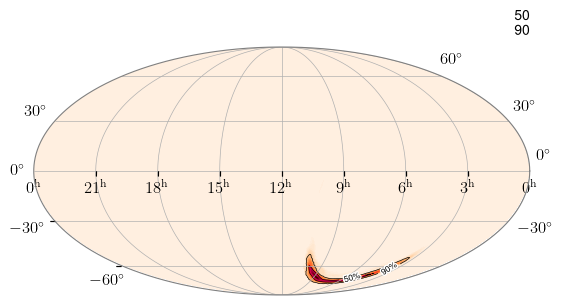

In [ ]:
t_gps = event_gps('GW150914')
print(f"GPS time for GW150914: {t_gps}")

# reading the GW150914 skymap
file = "skymaps/IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_cosmo_reweight_C01:Mixed.fits"
data = read(file)
data.plot()
plt.show()


In [3]:
det = Detector('H1') # LIGO Hanford

# Create a grid of Right Ascension (ra) and Declination (dec)
resolution = 100
declination = np.linspace(-np.pi/2, np.pi/2, resolution)
right_ascension = np.linspace(0, 2*np.pi, resolution)
RA, DEC = np.meshgrid(right_ascension, declination)

# Evaluate at a specific GPS time and polarization angle
t_gps = event_gps('GW150914')
pol = 0.0


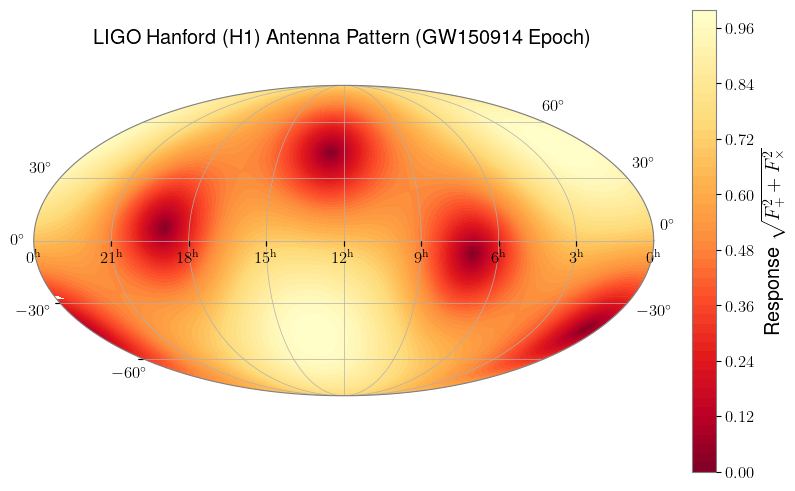

In [4]:
F_plus = np.zeros_like(RA)
F_cross = np.zeros_like(RA)

for i in range(RA.shape[0]):
    for j in range(RA.shape[1]):
        fp, fc = det.antenna_pattern(RA[i,j], DEC[i,j], pol, t_gps)
        F_plus[i,j] = fp
        F_cross[i,j] = fc

# Overall scalar sensitivity
response = np.sqrt(F_plus**2 + F_cross**2)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='astro hours mollweide')

cs = ax.contourf(
    np.degrees(RA),
    np.degrees(DEC),
    response,
    levels=50,
    cmap='YlOrRd_r',
    transform=ax.get_transform('world')
)
fig.colorbar(cs, ax=ax, label=r'Response $\sqrt{F_+^2 + F_\times^2}$')

ax.set_title('LIGO Hanford (H1) Antenna Pattern (GW150914 Epoch)', pad=30)
ax.grid(True)
plt.show()


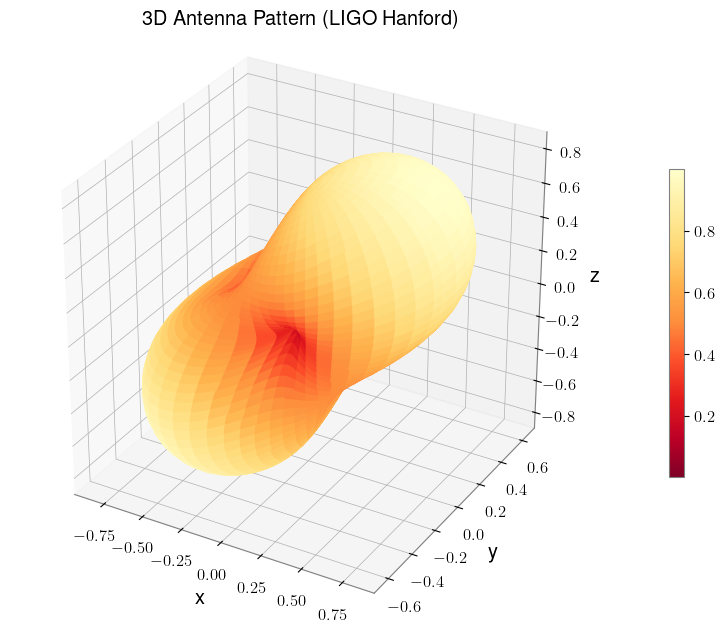

In [5]:
# 3D Visualization of the Antenna Pattern
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Transform spherical coordinates to Cartesian coordinates for 3D plotting
# We map the response magnitude to the radial coordinate
X = response * np.cos(DEC) * np.cos(RA)
Y = response * np.cos(DEC) * np.sin(RA)
Z = response * np.sin(DEC)

# Map the response surface to a colormap similar to the image
norm = plt.Normalize(response.min(), response.max())
colors = cm.YlOrRd_r(norm(response))

# Plot the 3D surface
surf = ax.plot_surface(X, Y, Z, facecolors=colors, shade=False, antialiased=True)

# Add a colorbar
m = cm.ScalarMappable(cmap=cm.YlOrRd_r, norm=norm)
m.set_array([])
plt.colorbar(m, ax=ax, shrink=0.5, pad=0.1)

# Set axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('3D Antenna Pattern (LIGO Hanford)')

# Maintain an equal aspect ratio so the "peanut" shape isn't stretched
ax.set_box_aspect([1, 1, 1])

plt.show()


### Understanding the 3D Geometry and the Mollweide Projection

**1. Why is the "peanut/donut" rotated and tilted?**
The shape represents the antenna response projected onto the *celestial sphere* (Right Ascension and Declination) at a *specific moment in time* (`t_gps = 1126259462.4`).
- **Earth's Orientation**: The LIGO Hanford (H1) detector is physically fixed to the surface of the Earth (at a specific latitude, longitude, and physical arm orientation).
- **Sidereal Time**: As the Earth rotates, the detector's zenith (straight up) sweeps across different Right Ascensions. Because we fixed the GPS time to the GW150914 epoch, the pattern is permanently "frozen" pointing at the patch of sky the detector was facing at exactly that second.
- If you were to increment `t_gps` by a few hours in the code, you would see this entire 3D peanut rotate around the Z-axis (which represents the Earth's celestial poles).

**2. Connecting the 3D shape to the 2D Mollweide Map**
The two plots are showing the exact same mathematical data, just mapped differently:
- **Radius vs. Color**: In the 3D plot, the distance from the center (the radius) is proportional to the detector's sensitivity. In the 2D Mollweide map, that same sensitivity is represented purely by the **color** (yellow is high, dark blue is zero).
- **The Maxima (Yellow Lobes)**: The two huge, wide bulges sticking out of the 3D shape correspond exactly to the two bright yellow blobs on the 2D map. This is the direction directly above and below the detector's X-Y plane (the zenith and nadir).
- **The Minima (Blind Spots)**: Notice how the 3D shape pinches inward and touches the origin (0,0,0) in 4 specific places. These are the detector's "blind spots" (angles exactly bisecting the detector arms, or exactly in the plane of the arms, where $F_+$ and $F_\times$ both vanish). If you look at the 2D Mollweide map, you will see exactly 4 dark-purple/blue "holes" or minimums.

Imagine taking the 3D peanut, wrapping a flat piece of paper around it as a sphere, coloring the paper based on how close the peanut's surface comes to touching it, and then unwrapping that paper into an oval flat map—that is the Mollweide projection!

## Build a new detector

In [ ]:
from pycbc.detector import Detector
from pycbc.detector import add_detector_on_earth

add_detector_on_earth(
    name = 'Indian_IFO',
    longitude = np.radians(19.09),
    latitude = np.radians(77.24),
    yangle = np.radians(90.0),
    xangle = np.radians(0.0),
    height = np.radians(0.0),
    xlength = 4.0,
    ylength = 4.0,
    xaltitude = 0.0,
    yaltitude = 0.0
)

ifo_custom = Detector('Indian_IFO')


## Questions

1. Compute the antenna pattern for the above newly defined detector.
2. Say, we have an event located at ra=7h, dec=0deg. How do you change the detector properties so that you can detect that signal?
